In [3]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split

# CNN setup
class SimpleCNN(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.activation = activation

        self.conv1 = nn.Conv2d(3, 32, 3) # (Convolution layer 1) Input: 3 channels (RGB), Output: 32 feature maps, Kernel size: 3x3
        self.conv2 = nn.Conv2d(32, 64, 3) # (Convolution layer 2) Takes 32 feature maps and produces 64
        self.pool = nn.MaxPool2d(2, 2) # (Max pooling) Reduces computation and extracts important features

        self.fc1 = nn.Linear(64 * 6 * 6, 128) # (Fully connected layer) Input: 64 feature maps that are 6x6, Output: 128 neurons
        self.fc2 = nn.Linear(128, 10) # (Final layer) Input: 128 neurons, Output: 10 classes because CIFAR-10 has 10 classes

    def forward(self, x):
        x = self.pool(self.activation(self.conv1(x))) # First conv layer → activation → pooling
        x = self.pool(self.activation(self.conv2(x))) # Second conv layer → activation → pooling
        x = x.view(-1, 64 * 6 * 6) # Flattens feature maps into a vector
        x = self.activation(self.fc1(x)) # Fully connected layer → activation
        x = self.fc2(x) # Final layer
        return x

# Training
def train_model(model, trainloader, valloader, optimizer, criterion, epochs=10):
    for epoch in range(epochs):
        # ---- TRAINING ----
        model.train()
        running_loss = 0.0

        for inputs, labels in trainloader:
            optimizer.zero_grad() # Resets gradients
            outputs = model(inputs) # Forward pass to get predictions
            loss = criterion(outputs, labels) # Computes loss
            loss.backward() # Backpropogation to compute gradients
            optimizer.step() # Update weights using optimizer

            running_loss += loss.item() # Adds batch loss to total loss
            
        train_loss = running_loss / len(trainloader)

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in valloader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(valloader)
        val_acc = 100 * correct / total

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.3f}, "
              f"Val Loss={val_loss:.3f}, "
              f"Val Acc={val_acc:.2f}%")

        
# Evaluation
def evaluate_model(model, testloader):
    model.eval()

    correct = 0
    total = 0

    # Disables gradient computation
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images) # Forward pass
            _, predicted = torch.max(outputs, 1) # Get predicted class
            total += labels.size(0) # Count total samples
            correct += (predicted == labels).sum().item() # Counts total correct predictions

    return 100 * correct / total


# -------------------------
# 1. Load MNIST
# -------------------------
transform_mnist = transforms.Compose([
    transforms.Resize((32, 32)),                  # match SVHN size
    transforms.Grayscale(num_output_channels=3),  # convert to 3 channels
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset_mnist = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_mnist
)

testset_mnist = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_mnist
)

# Loading dataset
train_size = int(0.8 * len(trainset_mnist))
val_size = len(trainset_mnist) - train_size

train_dataset, val_dataset = random_split(trainset_mnist, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
testloader_mnist = torch.utils.data.DataLoader(testset_mnist, batch_size=64, shuffle=False)

# -------------------------
# 2. Train CNN on MNIST
# -------------------------
model_mnist = SimpleCNN(F.leaky_relu)
criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = torch.optim.Adam(model_mnist.parameters(), lr=0.001)

print("Training on MNIST...")
train_model(model_mnist, trainloader, valloader, optimizer_mnist, criterion_mnist, epochs=5)

# Testing
#acc_mnist = evaluate_model(model_mnist, testloader_mnist)
#print("MNIST Accuracy:", acc_mnist)




Training on MNIST...
Epoch 1: Train Loss=0.159, Val Loss=0.060, Val Acc=98.15%
Epoch 2: Train Loss=0.045, Val Loss=0.040, Val Acc=98.92%
Epoch 3: Train Loss=0.029, Val Loss=0.037, Val Acc=98.95%
Epoch 4: Train Loss=0.019, Val Loss=0.036, Val Acc=98.97%
Epoch 5: Train Loss=0.016, Val Loss=0.034, Val Acc=99.08%
MNIST Accuracy: 99.04


In [5]:
# Save the model
torch.save(model_mnist, "cnn_task_2_4.pth")

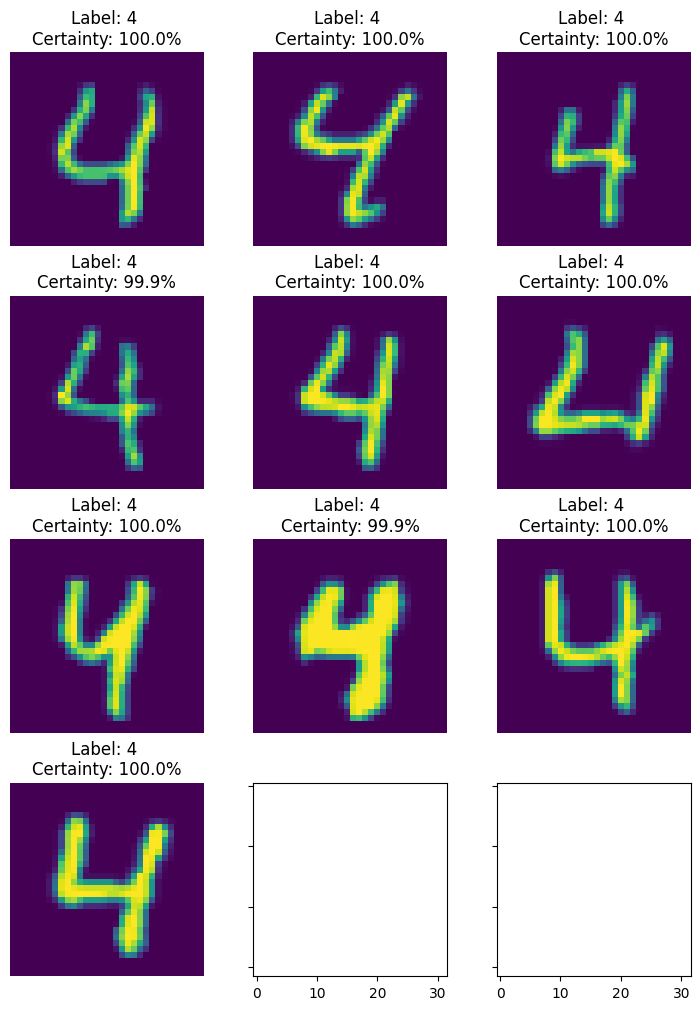

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
import tensorflow as tf

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import math

def plot_predictions(model, image_list, output_probs=False, adversarial=False):
    
    model.eval()

    with torch.no_grad():
        outputs = model(image_list)                  # forward pass
        probs = torch.softmax(outputs, dim=1)        # convert to probabilities

    prob = probs.cpu().numpy()

    pred_list = np.argmax(prob, axis=1)
    pct_list = np.max(prob, axis=1) * 100

    # Setup grid
    cols = 3
    rows = math.ceil(len(image_list) / cols)
    fig = plt.figure(figsize=(12., 12.))
    grid = ImageGrid(fig, 111, nrows_ncols=(rows, cols), axes_pad=0.5)

    for i in range(len(image_list)):
        # Convert tensor → numpy image
        img = image_list[i].cpu().permute(1, 2, 0).numpy()

        # Optional: undo normalization
        img = (img * 0.5) + 0.5

        img = img.mean(axis=2)

        grid[i].imshow(img, cmap='viridis')

        if (adversarial) and (i % 3 == 1):
            grid[i].set_title("Adversarial\nPartial Derivatives")
        else:
            grid[i].set_title(f"Label: {pred_list[i]} \nCertainty: {pct_list[i]:.1f}%")

        grid[i].axis('off')

    plt.show()

    return prob if output_probs else None



# Get 10 4s
targets = testset_mnist.targets

indices = (targets == 4).nonzero(as_tuple=True)[0]
index_of_4s = indices[:10]
x_batch = torch.stack([testset_mnist[i][0] for i in index_of_4s])

plot_predictions(model_mnist, x_batch)

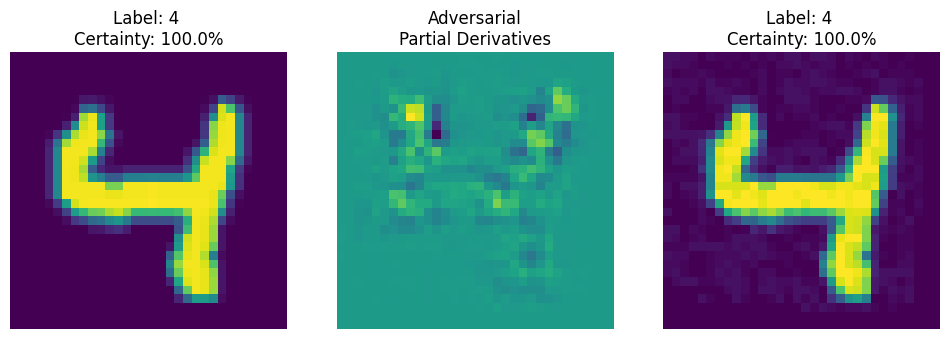

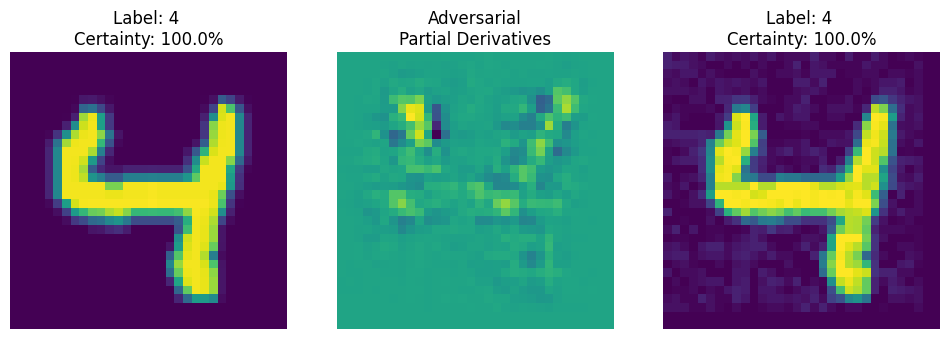

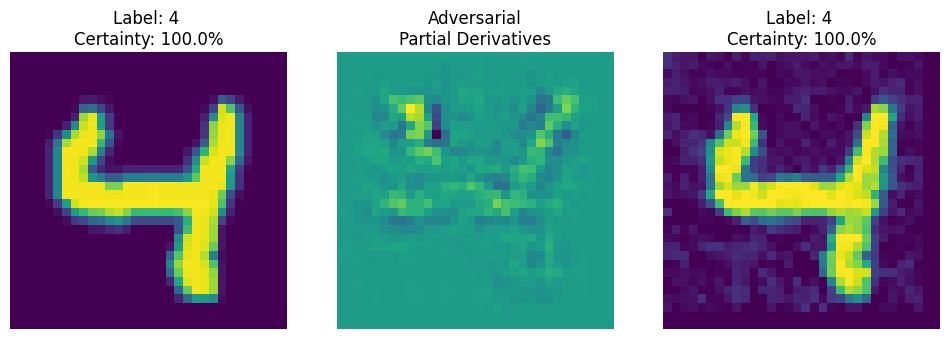

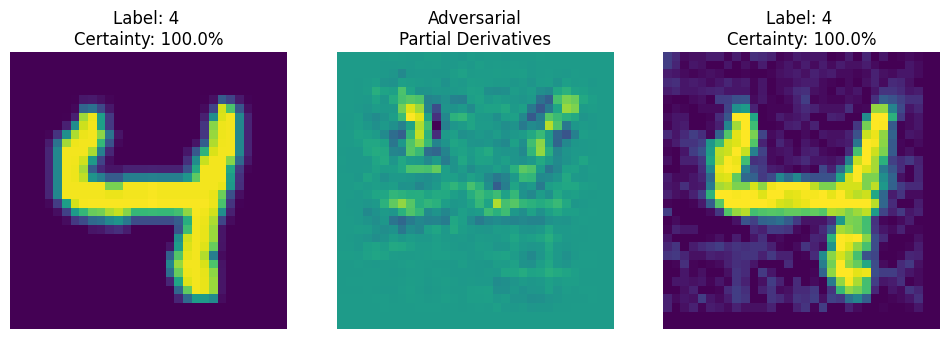

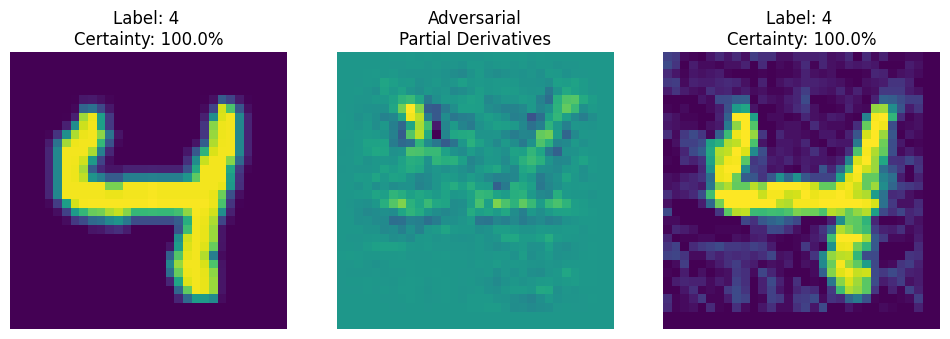

[]

In [40]:
import torch
import torch.nn.functional as F

def create_plot_adversarial_images(model, image, label, lr=0.001, n_steps=1, output_probs=False):
    
    model.eval()

    original_image = image.clone().detach()
    probs_per_step = []

    for _ in range(n_steps):
        image.requires_grad = True

        # Forward pass
        output = model(image)

        # Loss (label must be tensor shape [1])
        loss = F.cross_entropy(output, label)

        # Backprop to get gradient wrt image
        model.zero_grad()
        loss.backward()

        # Get gradient
        data_grad = image.grad.data

        # FGSM step
        image_adv = image - lr * torch.sign(data_grad)

        # Clamp to valid range
        image_adv = torch.clamp(image_adv, -1, 1)  # since normalized

        # Create visualization batch: original, gradient, adversarial
        img_adv_list = torch.cat([
            original_image,
            data_grad,
            image_adv.detach()
        ], dim=0)

        # Plot
        probs = plot_predictions(model, img_adv_list, output_probs=output_probs, adversarial=True)

        if output_probs:
            probs_per_step.append(probs)

        # Prepare for next step
        image = image_adv.detach()

    return probs_per_step

targets = testset_mnist.targets

index_of_4s = (targets[:1000] == 4).nonzero(as_tuple=True)[0]

rand_index = np.random.randint(0, len(index_of_4s))
idx = index_of_4s[rand_index]

image_norm, _ = testset_mnist[idx]
image_norm = image_norm.unsqueeze(0)

label_adv = torch.tensor([9]) # The label we want the model to guess

create_plot_adversarial_images(model_mnist, image_norm, label_adv, lr=0.09, n_steps=5)

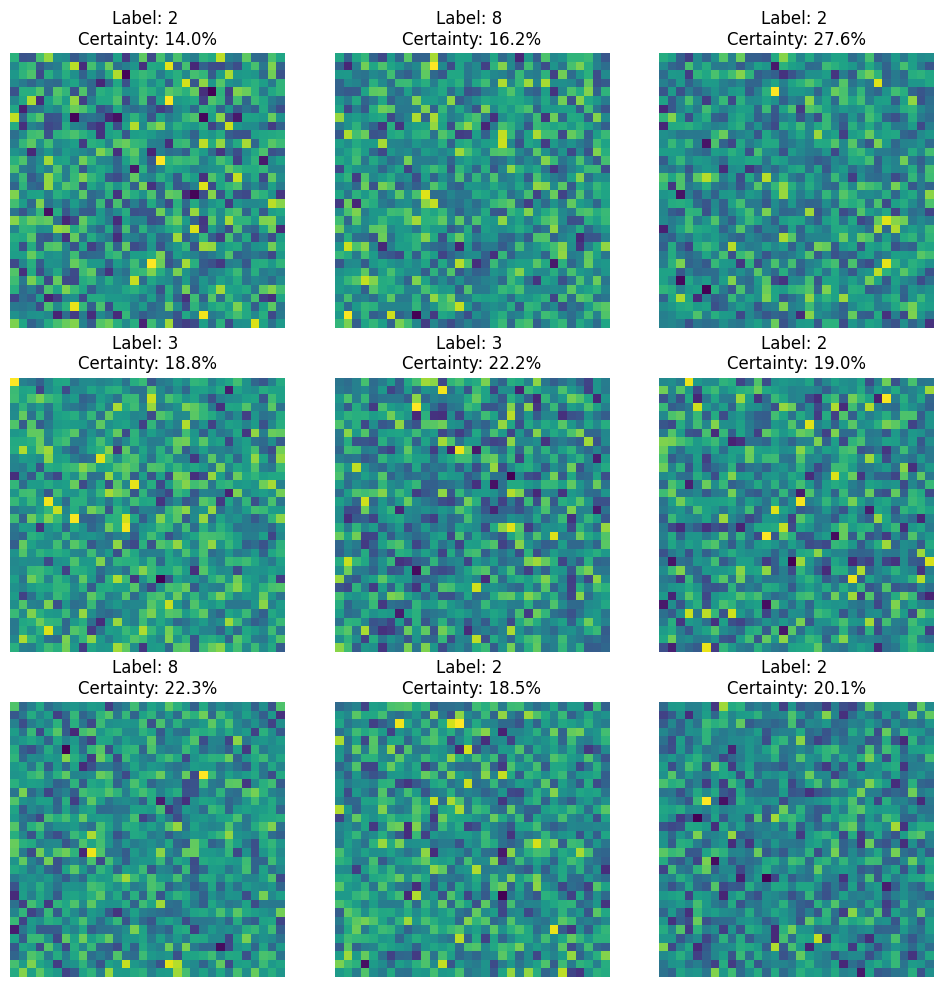

In [77]:
# Genererar en ny noisy image och ser vad den classifyar (den måste classifya pga softmax)
def generate_noise_images(num_images=10):
    noise = torch.randn(num_images, 3, 32, 32) * 0.5
    noise = torch.clamp(noise, -1, 1)
    return noise

noise_images = generate_noise_images(9)
plot_predictions(model_mnist, noise_images)

# Använder generate_noise_images och ändrar så den är confident att det är en nia
#def nine_noise(model, steps=20, lr=0.05):
#    image = generate_noise_images(1)
#    target = torch.tensor([9])

#    for _ in range(steps):
#        image.requires_grad = True
#        output = model(image)
#        loss = F.cross_entropy(output, target)

#        model.zero_grad()
#        loss.backward()
        
#        grad = image.grad.data
#        image = image - lr * torch.sign(grad)
#        image = torch.clamp(image, -1, 1).detach()
#    return image

#adv_noise = nine_noise(model_mnist)
#plot_predictions(model_mnist, adv_noise)


# Noise på MNIST (tror det är fel)
#def add_noise(images, noise_level=0.5):
#    noise = torch.randn_like(images)
#    noisy_images = images + noise_level * noise
#    noisy_images = torch.clamp(noisy_images, -1, 1)
#    return noisy_images

#noisy_batch = add_noise(x_batch, noise_level=1.5)
#combined_images = torch.cat([x_batch, noisy_batch], dim=0)
#plot_predictions(model_mnist, combined_images)